# Imports and constants

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import scipy.optimize as op

In [2]:
# Simulation data folders
dirpath_sim = "/net/debye/gmennella/randium/sims"
dirpath_sim_square = f"{dirpath_sim}/sims_layered_single_hex"

# Output folders
outdirpath_fig = "/net/debye/gmennella/randium/analysis/analysis_figure"
outdirpath_data = "/net/debye/gmennella/randium/analysis/analysis_data"

# Relax time criterion
overlap_target = .5

# Plot params.
fontsize_label = 15
fontsize_title = 16
fontsize_legend = 12

# Functions

In [3]:
def get_filepath(beta, version, device, dirpath=dirpath_sim_square):

    filepath = f"{dirpath}/runs_{version}/Data/{device}_48x48x48beta{beta:1.4f}.csv"

    return filepath

In [4]:
def find_relax_time(time_list, overlap_list, target=overlap_target):
    """"
    Find the relaxation time, defined as the time 
    such that the overlap value is equal to target.
    """

    # "Short" dynamics: overlap decreases to target.
    if (np.max(overlap_list) > target 
        and np.min(overlap_list) < target):

        time_idx = np.argmin(np.abs(overlap_list - target))
        relax_time = time_list[time_idx]

        return relax_time

    # "Long" dynamics: overlap decreases outside of
    # time window.
    else:

        return None    

# Short runs - Equilibration time:

## Data loading

In [7]:
# === Select beta values ===
beta_list_short_cpu = [
]
beta_list_short_gpu = [
    1.00, 1.10, 1.40
]

beta_list_short = np.array(beta_list_short_cpu + beta_list_short_gpu)

# === Load csv data ===
data_mat_short_cpu = [
    pd.read_csv(get_filepath(beta, version="L48_short", device="cpu"))
    for beta in beta_list_short_cpu
]
data_mat_short_gpu = [
    pd.read_csv(get_filepath(beta, version="L48_short", device="gpu"))
    for beta in beta_list_short_gpu
]

data_mat_short = data_mat_short_cpu + data_mat_short_gpu

# === Select time and overlap ===
time_mat_short = [
    np.array(data['time']) for data in data_mat_short
]

overlap_mat_short = [
    np.array(data['particle_overlap']) for data in data_mat_short
]

## Plot

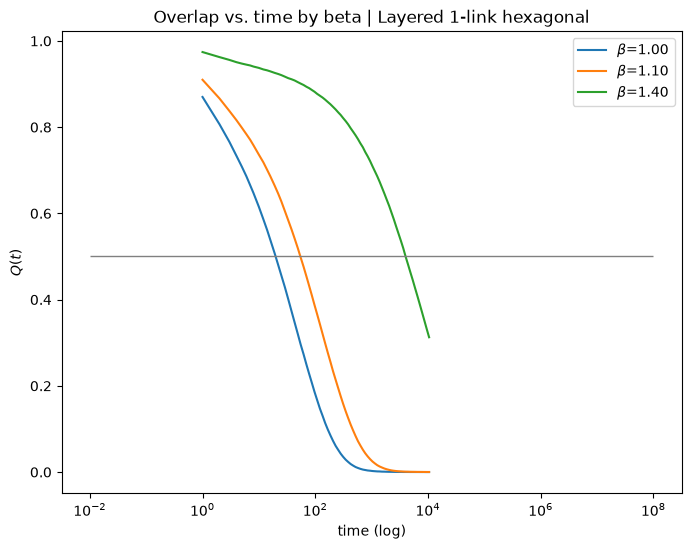

In [12]:
plt.figure(figsize=(8,6))

for time_list, overlap_list, beta in zip(
    time_mat_short,
    overlap_mat_short,
    beta_list_short,
    strict=True
):
    plt.plot(time_list, overlap_list, label=f'$\\beta$={beta:.2f}')

plt.hlines(overlap_target, 10**(-2), 10**8, colors='gray', linewidth=1)

plt.xscale("log")

plt.xlabel("time (log)")
plt.ylabel("$Q(t)$")
plt.title("Overlap vs. time by beta | Layered 1-link hexagonal")
plt.legend()

## Analysis - Relaxation time

In [13]:
tau_list_short = np.array([
    find_relax_time(time_list, overlap_list)
    for time_list, overlap_list in zip(time_mat_short, overlap_mat_short)
], dtype=float)

In [14]:
# Save results
filepath_save_tau = f"{outdirpath_data}/layered_single_hex_tau_vs_beta.dat"

header_save_tau = (
    "Layered Single-Link Hex lattice - Relaxation time tau "
    "vs inverse temperature beta. "
    "Note: include cases where tau is not found.\n"
    "beta | tau"
)

np.savetxt(
    fname=filepath_save_tau,
    X=np.transpose([beta_list_short, tau_list_short]),
    header=header_save_tau
)

## Plot - tau vs beta

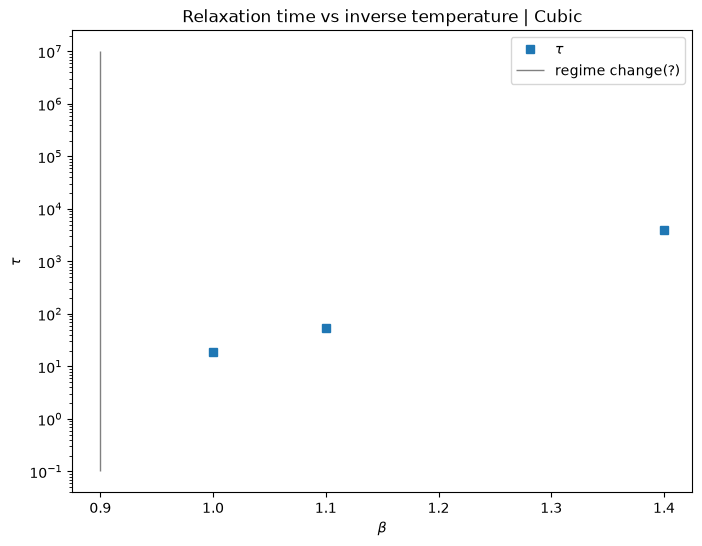

In [15]:
plt.figure(figsize=(8,6))

plt.plot(beta_list_short, tau_list_short, 's', label='$\\tau$')

plt.vlines(
    0.9, 
    ymin=0.1,
    ymax=10**7,
    label='regime change(?)',
    color='gray',
    linewidth=1
)

plt.yscale("log")

plt.xlabel("$\\beta$")
plt.ylabel("$\\tau$")
plt.title("Relaxation time vs inverse temperature | Cubic")
plt.legend()

## Fit - Relaxation time

In [16]:
def get_parabolic_fit_J_and_stdJ(a, var_a):
    """"
    Get J estimation and standard deviation from
    parabolic fit result.

    J = sqrt(a)
    var[J] = 0.25 / a * var[a]
    std[J] = sqrt(var[J])
    """

    J = np.sqrt(a)
    var_J = .25 / a * var_a
    std_J = np.sqrt(var_J)

    return J, std_J


def get_parabolic_fit_beta_q_and_std_beta_q(a, b, var_a, var_b, cov_ab):
    """"
    Get beta_q estimation and standard deviation from
    parabolic fit result.

    beta_q = -b / (2 * a)
    var[beta_q] = (0.5 * b / a**2)**2 * var[a] +
                    (0.5 / a)**2 * var[b] +
                    2 * (-0.25 * b / a**3) * cov[a,b]
    std[beta_q] = sqrt(var[beta_q])
    """

    beta_q = -b / (2 * a)
    dbeta_da = .5 * b / a**2
    dbeta_db = - .5 / a
    var_beta_q = (
        dbeta_da**2 * var_a + dbeta_db**2 * var_b
        + 2 * dbeta_da * dbeta_db * cov_ab
    )
    std_beta_q = np.sqrt(var_beta_q)

    return beta_q, std_beta_q


def get_parabolic_fit_log_tau_q_and_std_log_tau_q(
    a, b, c,
    var_a, var_b, var_c,
    cov_ab, cov_bc, cov_ac
):
    """"
    Get log(tau_q) estimation and standard deviation from
    parabolic fit result.

    log(tau_q) = c -b**2 / (4 * a)
    var[log(tau_q)] = ((0.5 * b / a**2)**2)**2 * var[a] +
                    + (-0.5 * b / a)**2 * var[b] +
                    + 1 * var[c] +
                    + 2 * (-(0.5 * b / a)**3) * cov[a,b] +
                    + 2 * (0.5 * b / a)**2 * cov[b,c] +
                    + 2 * (0.5 * b / a)**2 * cov[a,c]
    std[log(tau_q)] = sqrt(var[log(tau_q)])
    """

    log_tau_q = c - b**2 / (4 * a)
    dlog_tau_da = (.5 * b / a)**2
    dlog_tau_db = -.5 * b / a
    dlog_tau_dc = 1

    var_log_tau_q = (
        dlog_tau_da**2 * var_a + dlog_tau_db**2 * var_b + dlog_tau_dc * var_c
        + 2 * dlog_tau_da * dlog_tau_db * cov_ab 
        + 2 * dlog_tau_db * dlog_tau_dc * cov_bc
        + 2 * dlog_tau_da * dlog_tau_dc * cov_ac 
    )
    std_log_tau_q = np.sqrt(var_log_tau_q)

    return log_tau_q, std_log_tau_q


def get_parabolic_fit_tau_q_and_std_tau_q(log_tau_q, std_log_tau_q):
    """"
    Get tau_q estimation and standard deviation from
    parabolic fit result.

    tau_q = exp(log_tau_q)
    std[tau_q] = exp(log_tau_q) * std[log_tau_q]
    """

    tau_q = np.exp(log_tau_q)
    std_tau_q = np.exp(log_tau_q) * std_log_tau_q

    return tau_q, std_tau_q

Fitting parabolic scaling for beta >= 0.6


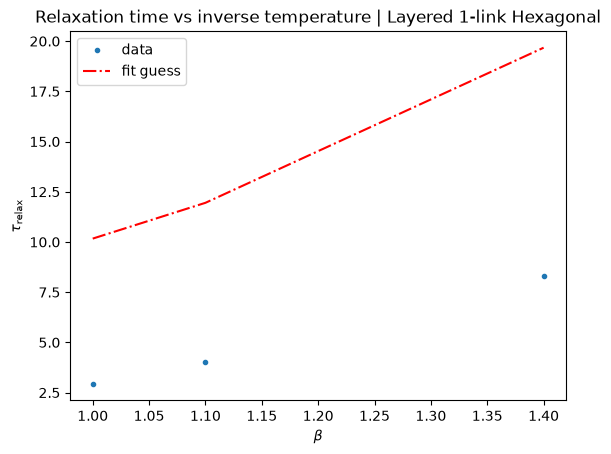

In [17]:
# ===== Data filtering =====
# Select beta range
beta_min_parabola = 0.6

print(f"Fitting parabolic scaling for beta >= {beta_min_parabola}")

# Filter nans for the plot
mask = (
    (beta_list_short >= beta_min_parabola)
    & (~np.isnan(tau_list_short))
)

beta_list_short_filter = beta_list_short[mask]
tau_list_short_filter = tau_list_short[mask]

# ===== Plot =====
# Data.
plt.plot(
    beta_list_short_filter, 
    np.log(tau_list_short_filter), 
    '.',
    label='data'
)

# Fit guess.
J_guess, beta_q_guess, tau_q_log_guess = 4.45, 0.6, 7
t_fit_guess = J_guess**2 * np.power(beta_list_short_filter - beta_q_guess, 2) + tau_q_log_guess

plt.plot(
    beta_list_short_filter,
    t_fit_guess,
    label='fit guess',
    color='red',
    linestyle='-.'
)

plt.xlabel("$\\beta$")
plt.ylabel("$\\tau_{\\text{relax}}$")
plt.title("Relaxation time vs inverse temperature | Layered 1-link Hexagonal")
plt.legend()